#TOI MODELLING (ENSEMBLE)


#1. Project Context

Ensemble Model Construction and Evaluation.

This notebook evaluates a heterogeneous soft-voting ensemble model for exoplanet classification using precomputed model probabilities. The objective is to improve classification reliability through ensemble aggregration and threshold optimisation.

#2. Declarations

In [ ]:
# PYTHON LIBRARIES
import warnings # Display warning messages

warnings.filterwarnings('ignore')

import calendar                 # Convert to names of month
import csv                      # Reading in CSV files
import numpy as np              # Operations on arrays
import pandas as pd             # Data manipulation and analysis
import datetime as dt           # Date and time manipulation
import math                     # Mathematical functions
import matplotlib.pyplot as plt # Python Visualisation
import seaborn as sns           # Seaborn library
import os                       # Operating System

import matplotlib.pyplot as plt  # Plots
import matplotlib.dates as mdate # Date manipulation for graphical display

# MAGIC COMMAND TO PLOT FIGURES IN THE NOTEBOOK
%matplotlib inline

from IPython import get_ipython
get_ipython().magic('reset -sf')

In [ ]:
# REPORTING METRICS

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,  ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, cohen_kappa_score, f1_score

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import mean_squared_error,r2_score             # RMSE, Chi-square

In [ ]:
# REPRODUCIBILITY

import numpy as np              # Operations on arrays

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# VERSION CTRL
import sklearn
print(sklearn.__version__)

1.6.1


#3. Load Required Files

##3.1. Test Data

Load data used in model probability calculation and ensemble construction and evaluation.

In [ ]:
from pathlib import Path
import pandas as pd   # Data manipulation and analysis

DATA_DIR = Path("../data")

y_test = pd.DataFrame()
y_test = pd.read_csv(DATA_DIR /"y_test.csv")
print(y_test.shape)
y_test.head()

(411, 1)


,tfopwg_disp_encoded
0,0
1,0
2,1
3,0
4,1


##3.2. Precomputed Probabilities

In [ ]:
import numpy as np

y_prob_SVC = np.load(DATA_DIR / "probs_SVC.npy")
y_prob_RF = np.load(DATA_DIR /"probs_RF.npy")
y_prob_LGBM = np.load(DATA_DIR / "probs_LGBM.npy")
y_prob_MLP = np.load(DATA_DIR / "probs_MLP.npy")

#4. Ensemble Probability Aggregration

Predicted probabilities from the base learners were combined via soft voting by averaging the class posterior probabilities produced by the Random Forest, Support Vector, LightGBM, and Multi-Layer Perceptron classifiers, on the same input samples.<br>
<br>
A fixed random seed (RANDOM_STATE = 42) was used during dataset splitting,resampling and model training to support reproducibility. Some ensemble probabilities shown in this notebook were generated during earlier experimental runs.

In [ ]:
# AVERAGE THE PROBABILITIES ACROSS MODELS

y_prob_ensemble = np.mean([
    y_prob_SVC,
    y_prob_RF,
    y_prob_LGBM,
    y_prob_MLP
], axis=0)


#5. Ensemble Evaluation

Classification accuracy of the ensemble model was benchmarked against published traditional models using the Receiver-Operating (ROC) and Precision-Recall (PR) curves. These were supported by Confusion matrices to quantify trade-offs between sensitivity and specificity.

##5.1. AUC Comparison Plot (ROC Overlay)

In [ ]:
# COMPUTE ROC CURVE AND AREA

# SVC
fpr_SVC_opt, tpr_SVC_opt, _ = roc_curve(y_test, y_prob_SVC)
roc_auc_SVC_opt = auc(fpr_SVC_opt, tpr_SVC_opt)

# RF
fpr_RF_opt, tpr_RF_opt, _ = roc_curve(y_test, y_prob_RF)
roc_auc_RF_opt = auc(fpr_RF_opt, tpr_RF_opt)

# LGBM
fpr_LGBM_opt, tpr_LGBM_opt, _ = roc_curve(y_test, y_prob_LGBM)
roc_auc_LGBM_opt = auc(fpr_LGBM_opt, tpr_LGBM_opt)

# MLP
fpr_MLP_opt, tpr_MLP_opt, _ = roc_curve(y_test, y_prob_MLP)
roc_auc_MLP_opt = auc(fpr_MLP_opt, tpr_MLP_opt)

# HYBRID ENSEMBLE
fpr_ensemble_thresh_default, tpr_ensemble_thresh_default, _ = roc_curve(y_test, y_prob_ensemble)
roc_auc_ensemble_thresh_default = auc(fpr_ensemble_thresh_default, tpr_ensemble_thresh_default)


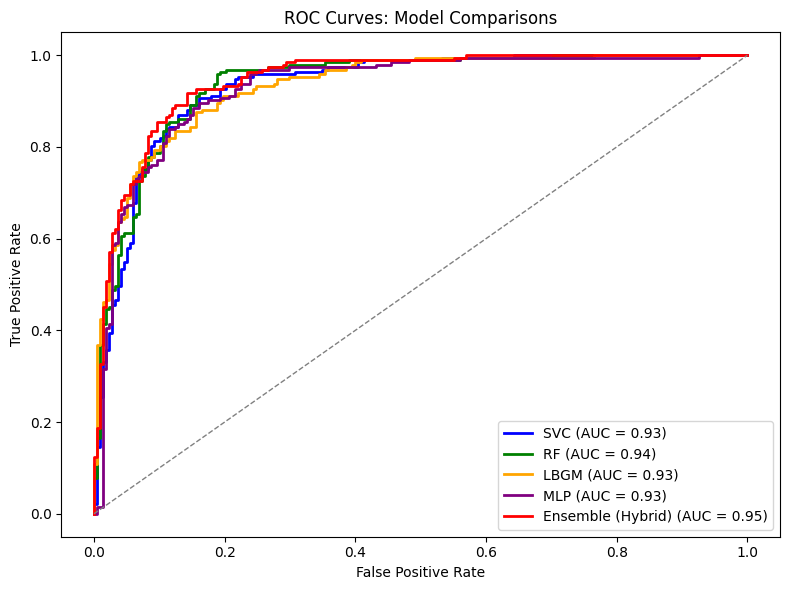

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_SVC_opt, tpr_SVC_opt, color='blue', lw=2, label=f'SVC (AUC = {roc_auc_SVC_opt:.2f})')
plt.plot(fpr_RF_opt, tpr_RF_opt, color='green', lw=2, label=f'RF (AUC = {roc_auc_RF_opt:.2f})')
plt.plot(fpr_LGBM_opt, tpr_LGBM_opt, color='orange', lw=2, label=f'LBGM (AUC = {roc_auc_LGBM_opt:.2f})')
plt.plot(fpr_MLP_opt, tpr_MLP_opt, color='purple', lw=2, label=f'MLP (AUC = {roc_auc_MLP_opt:.2f})')

# OPTIMUM HYBRID ENSEMBLE
plt.plot(fpr_ensemble_thresh_default, tpr_ensemble_thresh_default, color='red', lw=2, label=f'Ensemble (Hybrid) (AUC = {roc_auc_ensemble_thresh_default:.2f})')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Model Comparisons')
plt.legend()
plt.tight_layout()
plt.show()


##5.2. Precision-Recall (PR) Curve

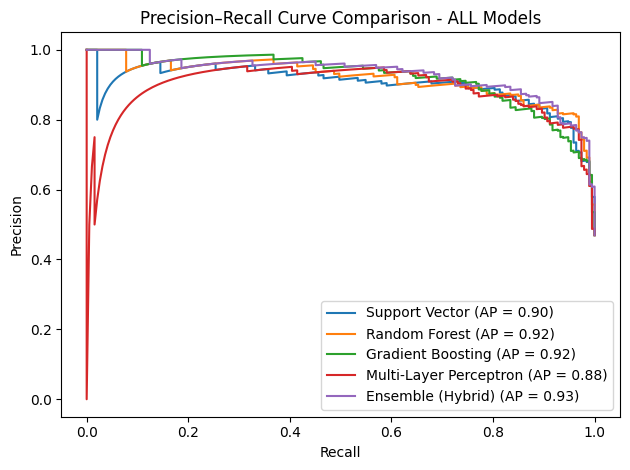

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


model_probs = {
    "Support Vector":y_prob_SVC,
    "Random Forest": y_prob_RF,
    "Gradient Boosting": y_prob_LGBM,
    "Multi-Layer Perceptron": y_prob_MLP
}

plt.figure()

for name, y_prob in model_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{name} (AP = {avg_precision:.2f})")


# ENSEMBLE MODEL
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_ensemble)
# precision, recall, _ = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_prob_ensemble)

plt.plot(recall, precision, label=f'Ensemble (Hybrid) (AP = {avg_precision:.2f})')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison - ALL Models")
plt.legend()
plt.tight_layout()
plt.show()

##5.3. Confusion Matrix

Apply a default threshold (0.5) for final prediction.

In [ ]:
y_pred_ensemble_thresh_default = (y_prob_ensemble > 0.5).astype(int)

In [ ]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_ensemble_thresh_default))
print("Unweighted Ensemble ROC AUC:", roc_auc_score(y_test, y_prob_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble_thresh_default))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       218
           1       0.85      0.89      0.87       193

    accuracy                           0.87       411
   macro avg       0.87      0.87      0.87       411
weighted avg       0.87      0.87      0.87       411

Unweighted Ensemble ROC AUC: 0.9468555402386272
Confusion Matrix:
 [[187  31]
 [ 21 172]]


In [ ]:
# EVALUATE THE MODEL
report = classification_report(y_test,y_pred_ensemble_thresh_default, output_dict=True)

# CONVERT THE REPORT TO A DATAFRAME
df_report = pd.DataFrame(report).transpose()


# RENAME THE INDEX LABELS
df_report.rename(index={'0': 'FALSE POSITIVE', '1': 'CONFIRMED'}, inplace=True)

# DISPLAY THE DATAFRAME
print(df_report, '\n')

                precision    recall  f1-score     support
FALSE POSITIVE   0.899038  0.857798  0.877934  218.000000
CONFIRMED        0.847291  0.891192  0.868687  193.000000
accuracy         0.873479  0.873479  0.873479    0.873479
macro avg        0.873165  0.874495  0.873311  411.000000
weighted avg     0.874738  0.873479  0.873592  411.000000 



In [ ]:
# Style the DataFrame
styled_report = df_report.style \
    .background_gradient(cmap='YlGnBu') \
    .set_caption('ENSEMBLE (Hybrid - Default) - Classification Report') \
    .format({'precision': '{:.2f}', 'recall': '{:.2f}', 'f1-score': '{:.2f}', 'support': '{:.0f}'}) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{
        'selector': 'caption',
        'props': 'caption-side: top; font-size: 16px; font-weight: bold;'
    }])

In [ ]:
plt.figure(figsize=(16, 16))
display(styled_report)

,precision,recall,f1-score,support
FALSE POSITIVE,0.90,0.86,0.88,218
CONFIRMED,0.85,0.89,0.87,193
accuracy,0.87,0.87,0.87,1
macro avg,0.87,0.87,0.87,411
weighted avg,0.87,0.87,0.87,411


<Figure size 1600x1600 with 0 Axes>

In [ ]:
# EVALUATE THE MODEL - CONFUSION MATRIX
conf_matrix = confusion_matrix(y_test, y_pred_ensemble_thresh_default)
f1 = f1_score(y_test, y_pred_ensemble_thresh_default, average='weighted')
# report = classification_report(y_test, y_predict_MLP_opt)
accuracy = balanced_accuracy_score(y_test, y_pred_ensemble_thresh_default)
kappa = cohen_kappa_score(y_test, y_pred_ensemble_thresh_default)

print(f"F1 Score: {f1}")
print(f"Kappa Score: {kappa}")
print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(report)


F1 Score: 0.8735918175622094
Kappa Score: 0.7467712505035664
Accuracy Score: 0.8744949374910871
Confusion Matrix:
[[187  31]
 [ 21 172]]
{'0': {'precision': 0.8990384615384616, 'recall': 0.8577981651376146, 'f1-score': 0.8779342723004695, 'support': 218.0}, '1': {'precision': 0.8472906403940886, 'recall': 0.8911917098445595, 'f1-score': 0.8686868686868687, 'support': 193.0}, 'accuracy': 0.8734793187347932, 'macro avg': {'precision': 0.8731645509662751, 'recall': 0.8744949374910871, 'f1-score': 0.8733105704936691, 'support': 411.0}, 'weighted avg': {'precision': 0.8747383898088655, 'recall': 0.8734793187347932, 'f1-score': 0.8735918175622094, 'support': 411.0}}


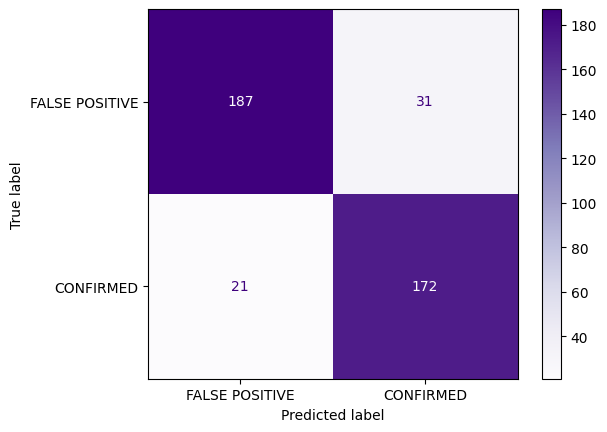

In [ ]:
# CREATE A CONFUSION MATRIX WITH CUSTOM LABELS

from sklearn.metrics import classification_report, confusion_matrix # Reporting Metrics

cm_ensemble = confusion_matrix(y_test, y_pred_ensemble_thresh_default)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble, display_labels=['FALSE POSITIVE', 'CONFIRMED'])

# PLOT THE CONFUSION MATRIX
disp.plot(cmap='Purples')
plt.show()

In [ ]:
# HYBRID ENSEMBLE
fpr_ensemble_thresh_default, tpr_ensemble_thresh_default, _ = roc_curve(y_test, y_prob_ensemble)
roc_auc_ensemble_thresh_default = auc(fpr_ensemble_thresh_default, tpr_ensemble_thresh_default)

#6. Decision Threshold Optimisation

##6.1. Youden Statistic (J) Threshold

To further address class imbalance. Youden's index, a disgnostic metric that maximises class separation, favouring sensitivity, was applied to the threshold.
Youden Threshold is a decision cut-off for detecting the positive class (e.g CONFIRMED - Class = 1). <br>
Youden Index optimises: <br>
- Sensitivity (TPR) -> detecting positives<br>
- Specificity (TNR) -> avoiding false alarms<br>

The threshold is determined such that it best separates likely positives and likely negatives along the P(Class = 1).<br>


In [ ]:
print('Optimised thresholds for unweighted ensemble:')

best_youden_thresh  = 0.464
best_youden_thresh

Optimised thresholds for unweighted ensemble:


0.464

In [ ]:
y_pred_ensemble_thresh_youden = (y_prob_ensemble > best_youden_thresh).astype(int)

##6.2. Optimised Evaluation

###6.2.1. Confusion Matrix

In [ ]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred_ensemble_thresh_youden))
print("Unweighted Ensemble ROC AUC:", roc_auc_score(y_test, y_prob_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble_thresh_youden))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       218
           1       0.85      0.91      0.88       193

    accuracy                           0.88       411
   macro avg       0.88      0.88      0.88       411
weighted avg       0.89      0.88      0.88       411

Unweighted Ensemble ROC AUC: 0.9468555402386272
Confusion Matrix:
 [[187  31]
 [ 17 176]]


In [ ]:
# EVALUATE THE MODEL
report = classification_report(y_test,y_pred_ensemble_thresh_youden, output_dict=True)

# CONVERT THE REPORT TO A DATAFRAME
df_report = pd.DataFrame(report).transpose()


# RENAME THE INDEX LABELS
df_report.rename(index={'0': 'FALSE POSITIVE', '1': 'CONFIRMED'}, inplace=True)

# DISPLAY THE DATAFRAME
print(df_report, '\n')

                precision    recall  f1-score     support
FALSE POSITIVE   0.916667  0.857798  0.886256  218.000000
CONFIRMED        0.850242  0.911917  0.880000  193.000000
accuracy         0.883212  0.883212  0.883212    0.883212
macro avg        0.883454  0.884858  0.883128  411.000000
weighted avg     0.885474  0.883212  0.883318  411.000000 



In [ ]:
# Style the DataFrame
styled_report = df_report.style \
    .background_gradient(cmap='YlGnBu') \
    .set_caption('ENSEMBLE (Hybrid - Youden) - Classification Report') \
    .format({'precision': '{:.2f}', 'recall': '{:.2f}', 'f1-score': '{:.2f}', 'support': '{:.0f}'}) \
    .set_properties(**{'text-align': 'center'}) \
    .set_table_styles([{
        'selector': 'caption',
        'props': 'caption-side: top; font-size: 16px; font-weight: bold;'
    }])

In [ ]:
plt.figure(figsize=(16, 16))
display(styled_report)

,precision,recall,f1-score,support
FALSE POSITIVE,0.92,0.86,0.89,218
CONFIRMED,0.85,0.91,0.88,193
accuracy,0.88,0.88,0.88,1
macro avg,0.88,0.88,0.88,411
weighted avg,0.89,0.88,0.88,411


<Figure size 1600x1600 with 0 Axes>

In [ ]:
# EVALUATE THE MODEL - CONFUSION MATRIX

conf_matrix = confusion_matrix(y_test, y_pred_ensemble_thresh_youden)
f1 = f1_score(y_test, y_pred_ensemble_thresh_youden, average='weighted')
accuracy = balanced_accuracy_score(y_test, y_pred_ensemble_thresh_youden)
kappa = cohen_kappa_score(y_test, y_pred_ensemble_thresh_youden)

print(f"F1 Score: {f1}")
print(f"Kappa Score: {kappa}")
print(f"Accuracy Score: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(report)


F1 Score: 0.8833182274189643
Kappa Score: 0.7665270183909678
Accuracy Score: 0.8848576317916053
Confusion Matrix:
[[187  31]
 [ 17 176]]
{'0': {'precision': 0.9166666666666666, 'recall': 0.8577981651376146, 'f1-score': 0.8862559241706162, 'support': 218.0}, '1': {'precision': 0.8502415458937198, 'recall': 0.9119170984455959, 'f1-score': 0.88, 'support': 193.0}, 'accuracy': 0.8832116788321168, 'macro avg': {'precision': 0.8834541062801933, 'recall': 0.8848576317916053, 'f1-score': 0.8831279620853081, 'support': 411.0}, 'weighted avg': {'precision': 0.8854743350141635, 'recall': 0.8832116788321168, 'f1-score': 0.8833182274189643, 'support': 411.0}}


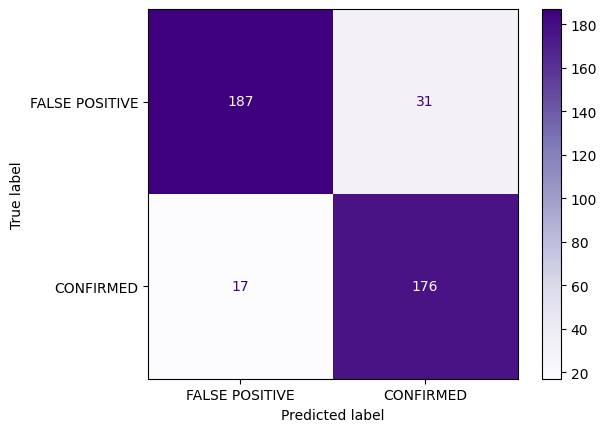

In [ ]:
# CREATE A CONFUSION MATRIX WITH CUSTOM LABELS

from sklearn.metrics import classification_report, confusion_matrix # Reporting Metrics

cm_ensemble_thresh_youden = confusion_matrix(y_test, y_pred_ensemble_thresh_youden)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_ensemble_thresh_youden, display_labels=['FALSE POSITIVE', 'CONFIRMED'])

# PLOT THE CONFUSION MATRIX
disp.plot(cmap='Purples')
plt.show()

The ensemble classifier achieved an accuracy of 88.3%, with balanced precision and recall across both classes, correctly identifying 176 out of 193 confirmed objects while rejecting 187 of 218 false positives, indicative of a well-calibrated and balanced decision strategy.

##6.2.2. AUC Comparison Plot (ROC Overlay)

In [ ]:
# COMPUTE FPR AND TPR FOR YOUDEN INDEX

# HYBRID ENSEMBLE
fpr_ensemble_thresh_youden, tpr_ensemble_thresh_youden, _ = roc_curve(y_test, y_prob_ensemble)
roc_auc_ensemble_thresh_youden = auc(fpr_ensemble_thresh_youden, tpr_ensemble_thresh_youden)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ensemble_thresh_youden).ravel()

tpr_ensemble_thresh_youden = tp / (tp + fn)          # Sensitivity
fpr_ensemble_thresh_youden = fp / (fp + tn)          # 1 - Specificity

tpr_ensemble_thresh_youden, fpr_ensemble_thresh_youden

(np.float64(0.9119170984455959), np.float64(0.14220183486238533))

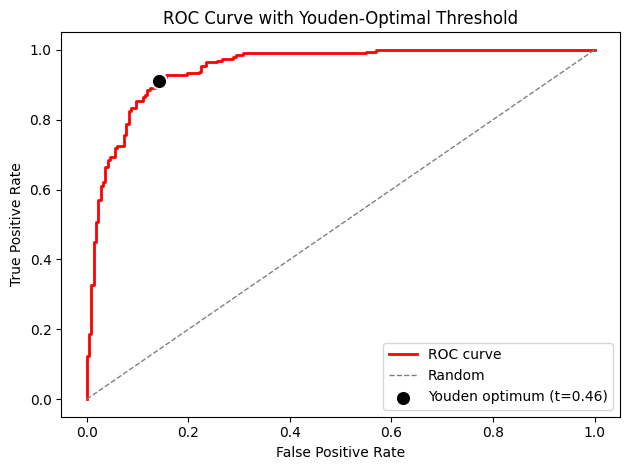

In [ ]:
# DETERMINE YOUDEN POINT FROM ROC CURVE

# ROC ENSEMBLE CURVE COMPUTED FROM Y_PROB_ENSEMBLE OVER ALL THRESHOLDS
# YOUDEN INDEX SELECTS ONE OPTIMAL THRESHOLD WHERE FPR/TPR AT YOUDEN IS A SINGLE POINT ON THE ROC ENSEMBLE
# CURVE

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure()

# PLOT ROC CURVE
plt.plot(fpr_ensemble_thresh_default, tpr_ensemble_thresh_default, color = "red", linewidth = 2, label="ROC curve")

# RANDOM CLASSIFIER LINE
plt.plot([0, 1], [0, 1], linestyle="--", color='grey', linewidth = 1, label="Random")

youden_optimal_threshold = best_youden_thresh

# YOUDEN OPTIMAL POINT
plt.scatter(
    fpr_ensemble_thresh_youden,
    tpr_ensemble_thresh_youden,
    s=120, # Marker size
    color="black",
    edgecolor = "white",
    linewidth = 1.5,
    zorder=5,
    label=f"Youden optimum (t={youden_optimal_threshold:.2f})"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Youden-Optimal Threshold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

##7. Key Findings


- The ensemble improved classification robustness relative to individual models.
- Threshold optimisation improved minority-class detection.
- ROC-AUC and Precision-Recall analysis demonstrated balanced performance.
- Soft-voting aggregation reduced prediction instability compared to relying on individual models alone.
- The workflow demonstrates the practical application of the ensemble learning and decision-threshold tuning for scientific classification tasks.<br>

Overall, the ensemble workflow demonstrated that combining heterogeneous models with threshold optimisation can improve classification reliability and interpretability.